### In this project, we work with a simulated advertising dataset that tracks whether an internet user clicks on an advertisement. The objective is to build a machine learning model that can predict whether a user will click on an ad based on their features.

### The dataset includes the following variables:

#### Daily Time Spent on Site: Time (in minutes) a user spends on the website
#### Age: Age of the user in years
#### Area Income: Average income of the user’s geographical area
#### Daily Internet Usage: Average number of minutes per day the user spends on the internet
#### Ad Topic Line: Headline or title of the advertisement
#### City: City where the user is located
#### Male: Gender indicator (1 = male, 0 = female)
#### Country: Country of the user
#### Timestamp: The time when the user clicked the ad or exited the page
#### Clicked on Ad: Target variable (1 = clicked, 0 = not clicked)

# Importing Libraries and Getting the Data

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
data = pd.read_csv('advertising.csv')

### Using head, info and describe on dataset

In [4]:
data.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,3/27/2016 0:53,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,4/4/2016 1:39,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,3/13/2016 20:35,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,1/10/2016 2:31,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,6/3/2016 3:36,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.2+ KB


In [6]:
data.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


## Exploratory Data Analysis

### Create a histogram of the Age

<AxesSubplot:ylabel='Frequency'>

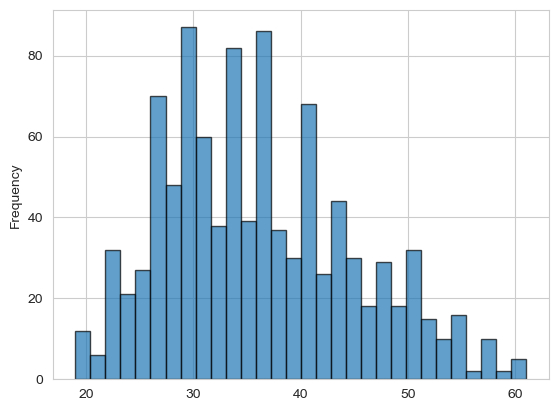

In [7]:
sns.set_style("whitegrid")
data['Age'].plot.hist(bins=30, edgecolor='black', alpha=0.7)

✅ Range: Values go roughly from ~18 to ~60.

✅ Peak (mode): Most data points are concentrated between ~28 and ~40, with the highest bars around the low-to-mid 30s.

✅ Shape: The distribution looks roughly bell-shaped (normal-like) but slightly right-skewed (there are more values stretching toward higher numbers like 50–60).

✅ Spread: There’s a decent spread, but fewer observations at the extremes (very low and very high values).

✅ Outliers: No obvious extreme outliers, though values above 55–60 are relatively rare.

## Creating a jointplot showing Area Income versus Age.

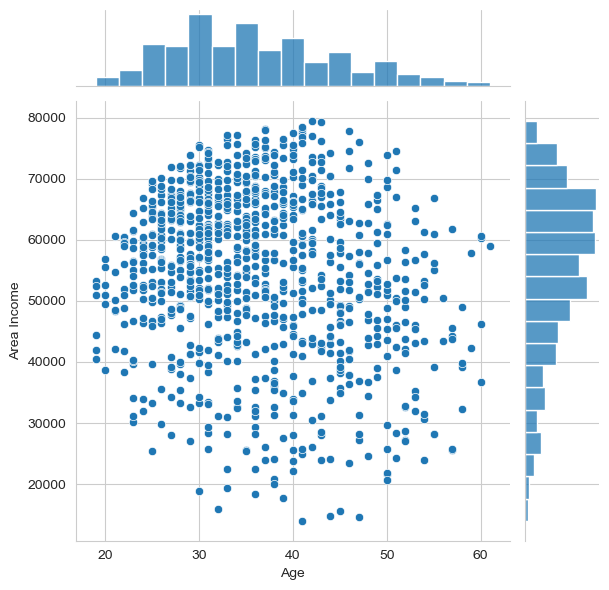

In [8]:
sns.set_style("whitegrid")
sns.jointplot(x='Age',y='Area Income', data=data)

### 🔍 1. Relationship between Age & Area Income
#### The points are widely scattered, so there’s no strong linear relationship.
#### At best, there might be a very weak trend, but nothing clearly increasing or decreasing.

#### 👉 Conclusion: Age alone is not a strong predictor of Area Income.

### 📊 2. Age Distribution (Top Histogram)
#### Most users fall between ~25 and 40 years.
#### Fewer people are very young (<20) or older (>55).
#### 👉 This matches a typical working-age population.

### 💰 3. Area Income Distribution (Right Histogram)
#### Most incomes are between ~45,000 and 70,000.
#### Peak density seems around 55k–65k.
#### Very low (<20k) and very high (>75k) incomes are rare.

### 📌 4. Density Insight
#### The highest concentration of points is around:
#### Age: 28–38
#### Income: 50k–70k


## Creating a jointplot showing the kde distributions of Daily Time spent on site vs. Age.

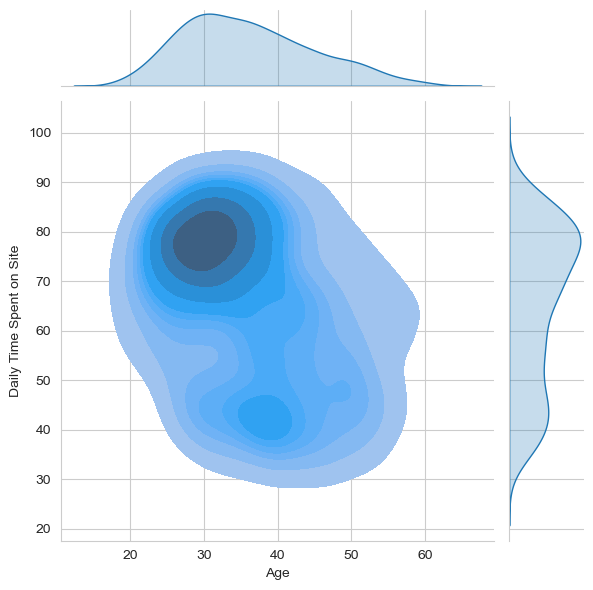

In [9]:
sns.jointplot(x='Age',y='Daily Time Spent on Site',data=data,kind='kde',fill=True)

### 🧠 Simple takeaway:
#### Younger users are more engaged (spend more time on site).
#### Engagement drops with age.
#### There are two behavioral groups:
#### High engagement (younger users)
#### Moderate/low engagement (older users)

## Creating a jointplot of 'Daily Time Spent on Site' vs. 'Daily Internet Usage'

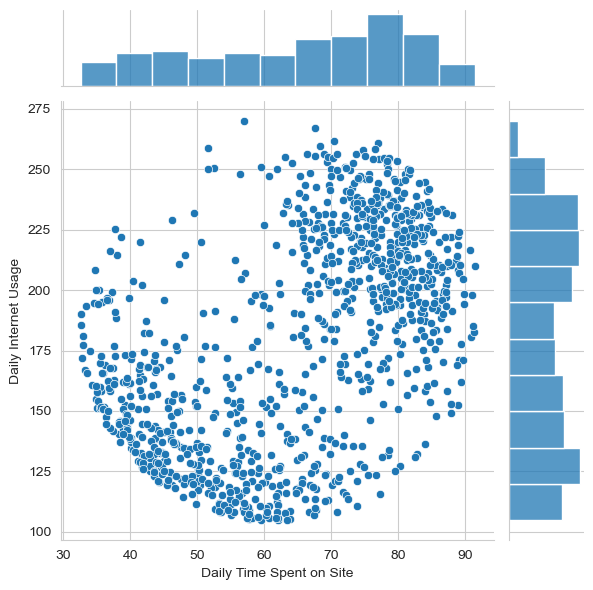

In [10]:
sns.set_style("whitegrid")
sns.jointplot(x='Daily Time Spent on Site',y='Daily Internet Usage',data=data)

### 🧠 Simple takeaway:
### Users fall into different behavioral groups, not a single trend.
### High internet usage often aligns with higher engagement, but not always.
### This feature pair could be very useful for classification (ad click prediction).

## Finally,Let's  create a pairplot with the hue defined by the 'Clicked on Ad' column feature.

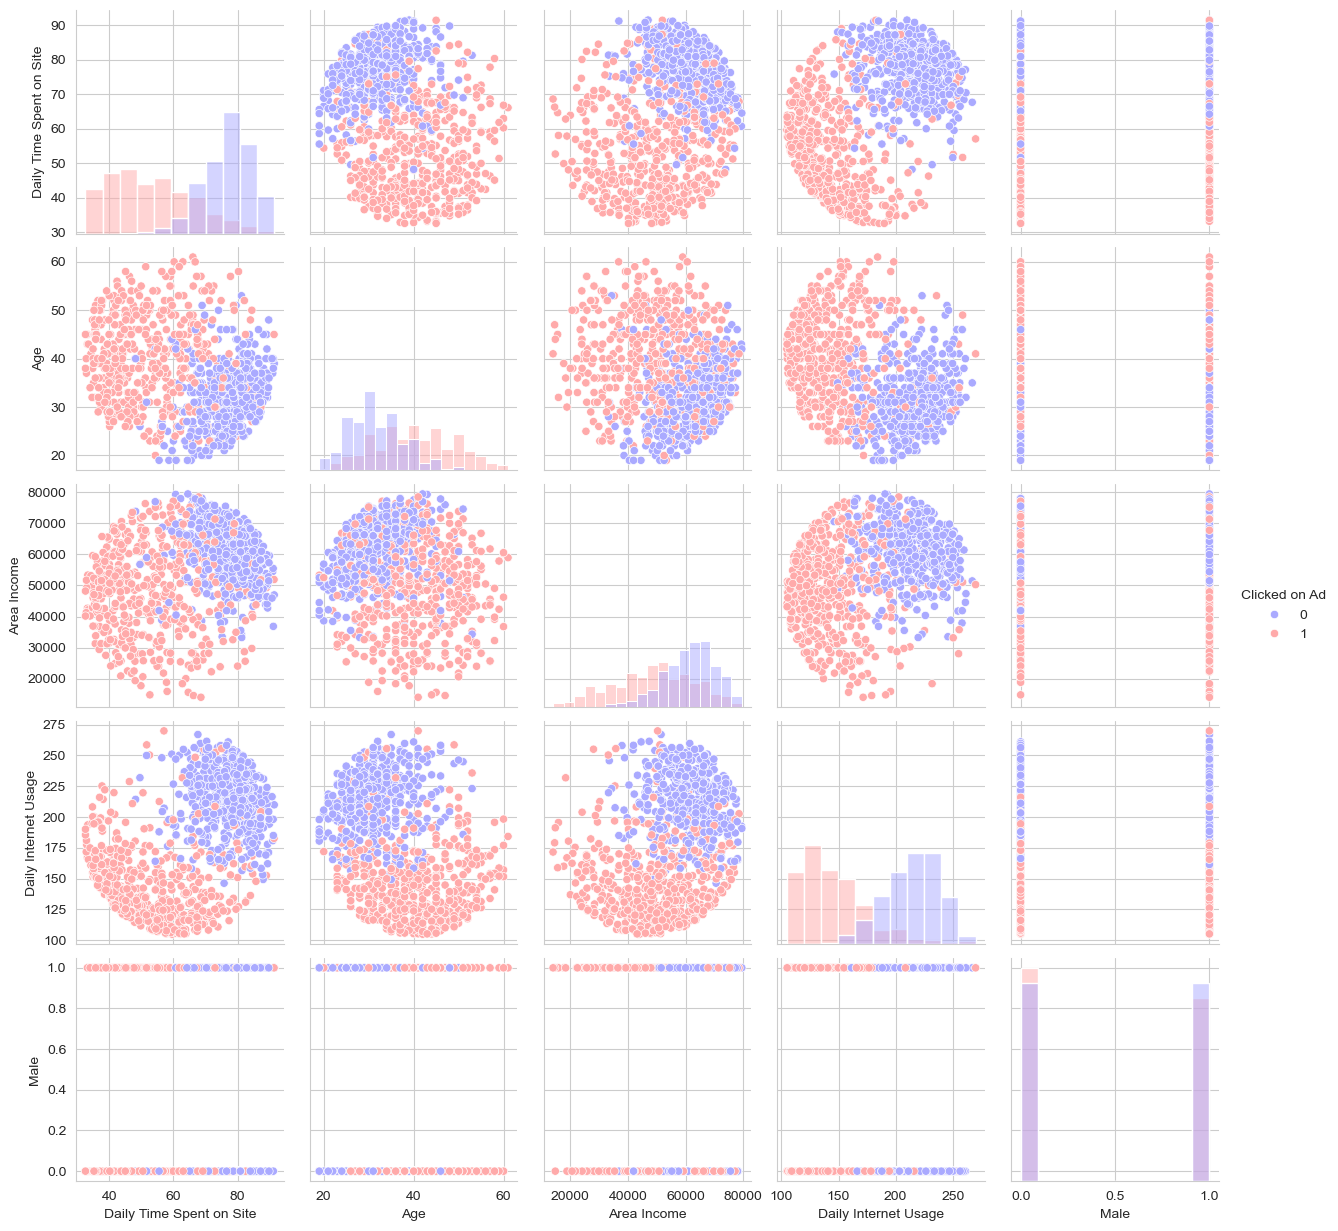

In [11]:
sns.pairplot(data,hue='Clicked on Ad',diag_kind='hist',palette='bwr')

## 🏆 Final Takeaway 

#### 👉 A user is more likely to click an ad if they are:

#### Older
#### Spend less time on the site
#### Have lower internet usage
#### Have lower income

#### 👉 A user is less likely to click if they are:

#### Younger
#### Highly engaged (spend more time)
#### Heavy internet users
#### Higher income

# Logistic Regression
### Now it's time to do a train test split, and train our model!

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X= data[['Daily Time Spent on Site','Age','Area Income','Daily Internet Usage','Male']]
y= data['Clicked on Ad']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.33, random_state=101)

In [14]:
from sklearn.linear_model import LogisticRegression

In [15]:
logmodel = LogisticRegression(max_iter=500)
print(logmodel.fit(X_train,y_train))

LogisticRegression(max_iter=500)


In [16]:
predictions = logmodel.predict(X_test)

# Creating classification report for the model

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       171
           1       0.99      0.97      0.98       159

    accuracy                           0.98       330
   macro avg       0.98      0.98      0.98       330
weighted avg       0.98      0.98      0.98       330



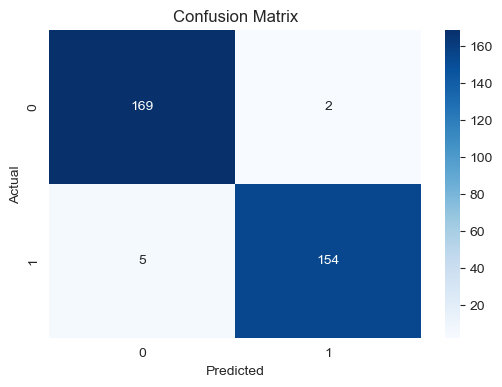

In [18]:

from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test, predictions))

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()